---
title: "Titanic"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Titanic Passengers
- **description:** Passenger-level records of who survived the 1912 sinking of the RMS Titanic, with demographic, family, and fare details.
- **provenance:** Derived from the passenger manifest; popularized through Encyclopedia Titanica and the Kaggle "Titanic" machine-learning competition.
- **format:** long / tidy — 891 rows x 15 columns (several columns are redundant or derived).

**Data dictionary**

- `survived` — *(measurement / outcome)* 0 = died, 1 = survived.
- `pclass` / `class` — *(identifier)* ticket class, 1–3 / First–Third.
- `sex`, `who`, `adult_male` — *(identifier)* sex, and man/woman/child grouping.
- `age` — *(measurement)* age in years.
- `sibsp`, `parch` — *(measurement)* siblings/spouse and parents/children aboard.
- `fare` — *(measurement)* fare paid.
- `embarked` / `embark_town` — *(identifier)* port of embarkation (C/Q/S).
- `deck` — *(identifier)* cabin deck (mostly missing).
- `alive`, `alone` — *(derived)* text survival flag and lone-traveler flag.

**Structure**

- **Rows:** 891 — one row per passenger.
- **Columns:** 15.
- **Identifiers:** `sex`, `class`/`pclass`, `who`, `embarked`, `deck`.
- **Measurements:** `age`, `fare`, `sibsp`, `parch`; `survived` is the outcome.

**Use cases**

- survival-rate cross-tabulations by class, sex, and age group
- grouped and stacked bar charts
- categorical aggregation and augmentation


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

## Long form (tidy)

In [3]:
titanic = sns.load_dataset('titanic')
titanic.info()
titanic.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Long form, augmented

In [4]:
titanic.loc[(titanic.who.isin(['man','woman'])), 'age_group'] = 'adult'
titanic.loc[titanic.who.isin(['child']), 'age_group'] = 'child'
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,adult


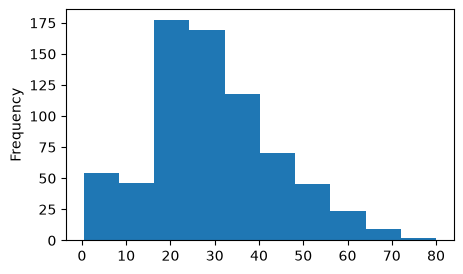

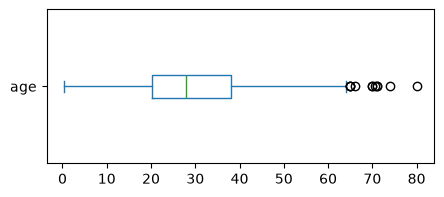

In [62]:
titanic.age.plot.hist(figsize=(5,3))
plt.show()
titanic.age.plot.box(vert=False, figsize=(5,2))
plt.show()

## Wide form, aggregated 1 by 1

These are wide forms generated by the simple count aggregation of survival rate by single categories.

In [73]:
N = titanic.shape[0]

In [84]:
titanic1a = titanic.value_counts(['class','survived']).unstack()
titanic1a

survived,0,1
class,,
First,80,136
Second,97,87
Third,372,119


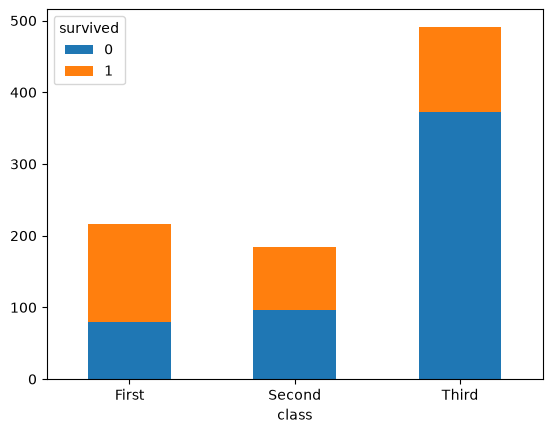

In [89]:
titanic1a.plot.bar(stacked=True, rot=0)
plt.show()

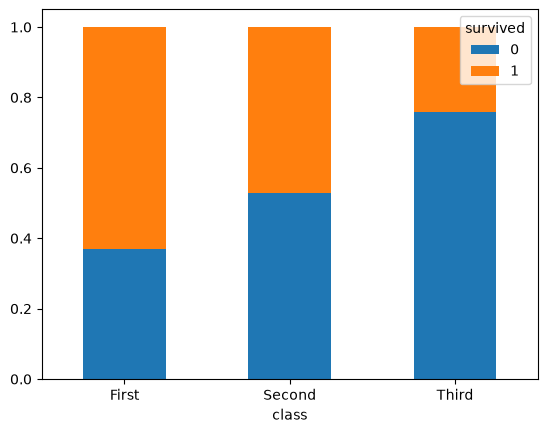

In [104]:
titanic1a.div(titanic1a.sum(axis=1), axis=0).plot.bar(stacked=True, rot=0)
plt.show()

In [78]:
titanic1b = titanic.value_counts(['sex','survived']).unstack()
titanic1b

survived,0,1
sex,,
male,0.525253,0.122334
female,0.090909,0.261504


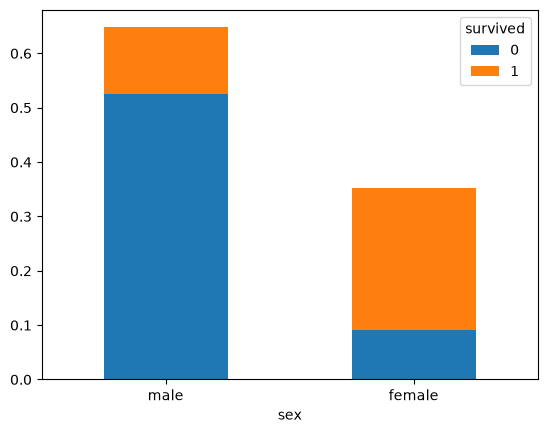

In [90]:
titanic1b.plot.bar(stacked=True, rot=0)
plt.show()

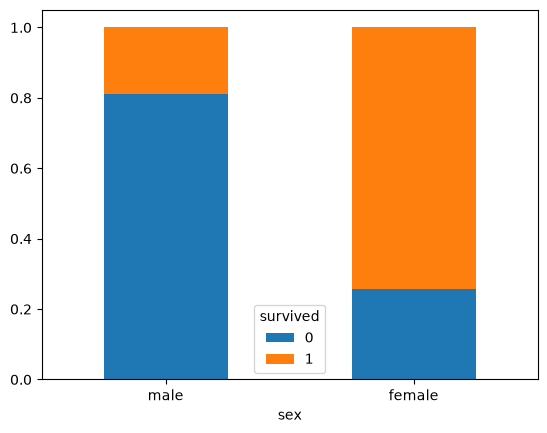

In [105]:
titanic1b.div(titanic1b.sum(axis=1), axis=0).plot.bar(stacked=True, rot=0)
plt.show()

In [80]:
titanic1c = titanic.value_counts(['age_group','survived']).unstack() / N
titanic1c

survived,0,1
age_group,,
adult,0.578002,0.328844
child,0.038159,0.054994


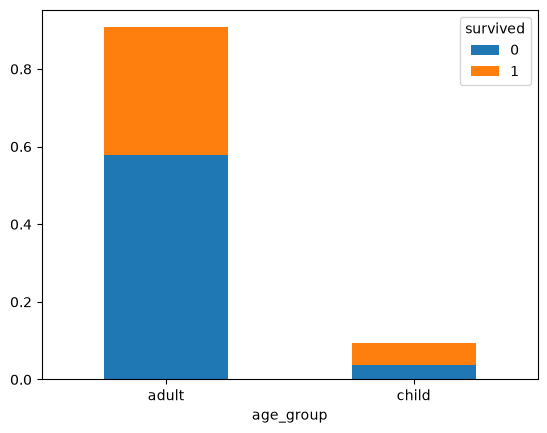

In [91]:
titanic1c.plot.bar(stacked=True, rot=0)
plt.show()

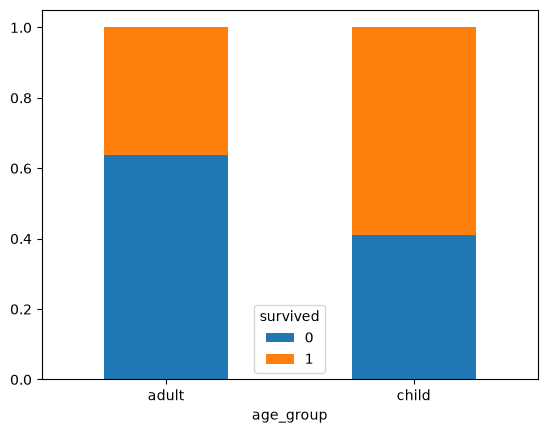

In [106]:
titanic1c.div(titanic1c.sum(axis=1), axis=0).plot.bar(stacked=True, rot=0)
plt.show()

## Viewed as subplots

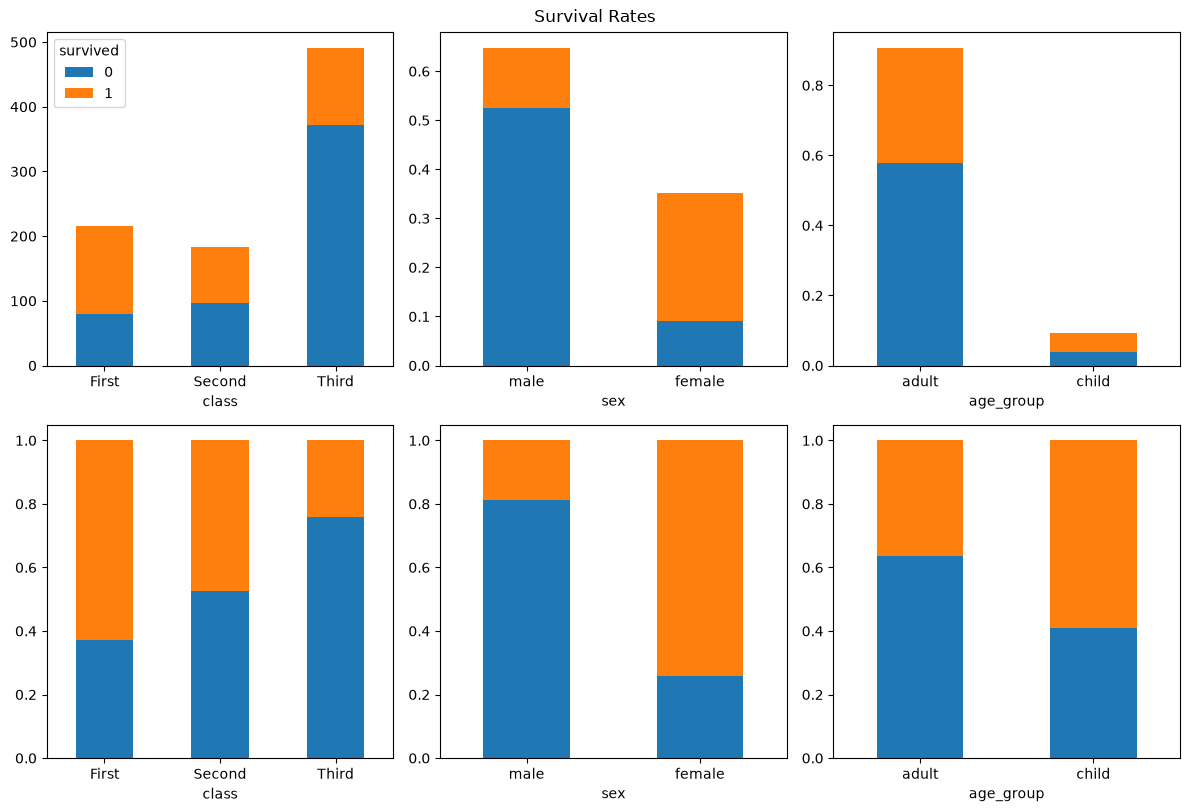

In [140]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
titanic1a.plot.bar(stacked=True, rot=0, ax=ax[0,0])
titanic1b.plot.bar(stacked=True, rot=0, ax=ax[0,1], legend=False)
titanic1c.plot.bar(stacked=True, rot=0, ax=ax[0,2], legend=False)
titanic1a.div(titanic1a.sum(axis=1), axis=0).plot.bar(stacked=True, rot=0, ax=ax[1,0], legend=False)
titanic1b.div(titanic1b.sum(axis=1), axis=0).plot.bar(stacked=True, rot=0, ax=ax[1,1], legend=False)
titanic1c.div(titanic1c.sum(axis=1), axis=0).plot.bar(stacked=True, rot=0, ax=ax[1,2], legend=False)
plt.tight_layout()
plt.suptitle("Survival Rates", y=1.01)
plt.show()

## Long form, aggregated with three identifiers

In [115]:
key_cols = ['sex', 'class', 'age_group']
titanic2 = titanic.groupby(key_cols).agg(
    survived_sum = ('survived', 'sum'),
    person_count = ('survived', 'count')
)
titanic2['survival_rate'] = titanic1.survived_sum / titanic1.person_count
titanic2.sort_index()

survived_sum  person_count  survival_rate
sex    class  age_group                                           
female First  adult                89            91       0.978022
              child                 2             3       0.666667
       Second adult                60            66       0.909091
              child                10            10       1.000000
       Third  adult                56           114       0.491228
              child                16            30       0.533333
male   First  adult                42           119       0.352941
              child                 3             3       1.000000
       Second adult                 8            99       0.080808
              child                 9             9       1.000000
       Third  adult                38           319       0.119122
              child                 9            28       0.321429

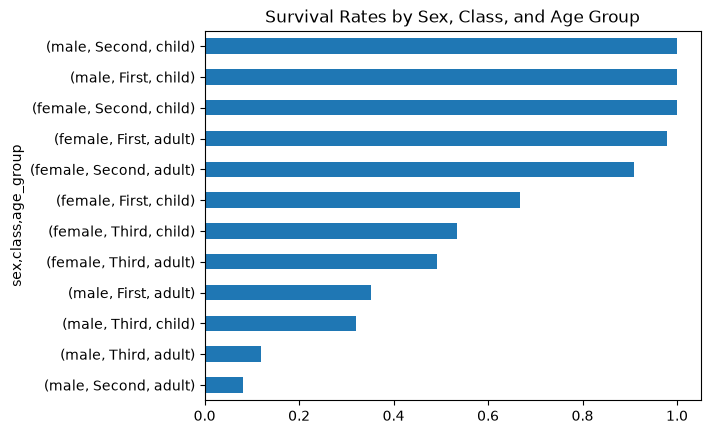

In [116]:
titanic2.survival_rate.sort_values().plot.barh(title="Survival Rates by Sex, Class, and Age Group")
plt.show()

## Wide form, aggregated 1 by 1

Note that the probabalities are conditional on the population that includes children, so the rows and columns will not sum to 1.

In [118]:
titanic3a = titanic2.survival_rate.unstack().adult.unstack()
titanic3a

class,First,Second,Third
sex,,,
female,0.978022,0.909091,0.491228
male,0.352941,0.080808,0.119122


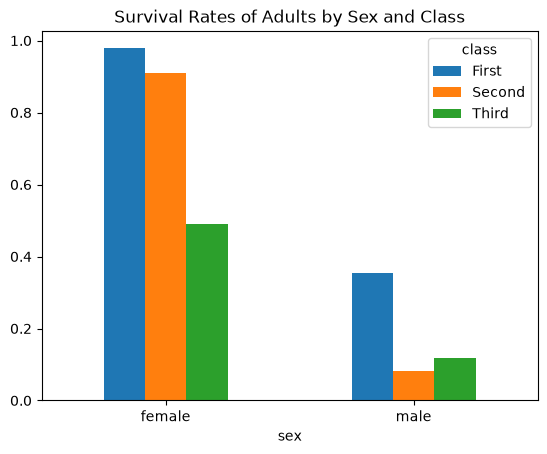

In [119]:
titanic3a.plot.bar(rot=0, title="Survival Rates of Adults by Sex and Class")
plt.show()

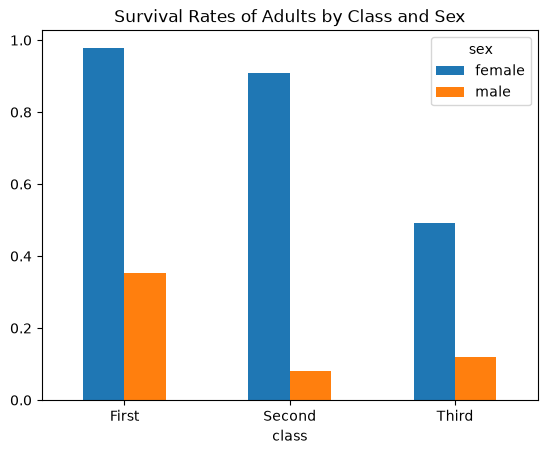

In [120]:
titanic3a.T.plot.bar(rot=0, title="Survival Rates of Adults by Class and Sex")
plt.show()